In [ ]:
!pip install --upgrade pip
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.8.0+cu126.html

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html


In [ ]:
!pip install albumentations grad-cam

In [ ]:
'''
# ================== ADVANCED CNN+GAT DEEPFAKE DETECTION PIPELINE ==================
# Includes: Data Augmentation, Pretrained CNN, Efficient GAT, Focal Loss, Early Stopping, AMP,
#           Learning Rate Scheduling, Model Checkpointing, and Imbalance Handling
Key improvements:
- Unfreeze last block of CNN for fine-tuning
- Stronger data augmentation (Albumentations)
- Early stopping, LR scheduler, AMP

- Modularized and clean
'''
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GATConv, global_mean_pool, SAGEConv
from torch_geometric.utils import dropout_edge
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from torch_geometric.data import Data as GraphData, Batch
from torch_geometric.loader import DataLoader as PyGDataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

import kagglehub


In [ ]:
# Download latest version   ### another dataset use any one
path = kagglehub.dataset_download("manishkumarcgh/deepfake-and-images")

print("Path to dataset files:", path)

NameError: name 'kagglehub' is not defined

In [ ]:
# ========== DATA DOWNLOAD ==========
path = kagglehub.dataset_download("tusharpadhy/deepfake-dataset")
print("Path to dataset files:", path)
DATASET_PATH = path

100%|██████████| 5.42G/5.42G [01:03<00:00, 92.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tusharpadhy/deepfake-dataset/versions/1


In [ ]:
# ========== SETTINGS ==========
IMG_SIZE = 128           # Reduced for speed/cost
PATCH_SIZE = 24         # Larger patches reduce graph size
BATCH_SIZE = 724      # Larger batch if memory allows (faster)
NUM_CLASSES = 2
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

N_EPOCHS = 10
PATIENCE = 8            # Early stopping
LR = 2e-4


In [ ]:

# ========== DATA AUGMENTATION ==========
def get_train_aug():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, p=0.5),
        A.OneOf([
            A.GaussNoise(var_limit=(10.0, 50.0)),
            A.MotionBlur(blur_limit=5),
            A.Blur(blur_limit=3),
        ], p=0.5),
        A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05, p=0.5),
        A.CoarseDropout(max_holes=4, max_height=12, max_width=12, fill_value=0, p=0.5),
        A.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ToTensorV2()
    ])

def get_test_aug():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ToTensorV2()
    ])

class AlbumentationsTransform:
    def __init__(self, aug):
        self.aug = aug
    def __call__(self, img):
        return self.aug(image=np.array(img))["image"]

# ========== IMAGE TO PATCH-GRAPH ==========
def image_to_graph_patches(image_tensor, label, patch_size=PATCH_SIZE):
    C, H, W = image_tensor.shape
    num_rows = H // patch_size
    num_cols = W // patch_size
    node_features = []
    for i in range(num_rows):
        for j in range(num_cols):
            patch = image_tensor[:, i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            feature = patch.mean(dim=[1,2])
            node_features.append(feature)
    x = torch.stack(node_features)
    edge_index = []
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            neighbors = []
            if i > 0: neighbors.append(((i - 1) * num_cols + j))
            if i < num_rows - 1: neighbors.append(((i + 1) * num_cols + j))
            if j > 0: neighbors.append((i * num_cols + (j - 1)))
            if j < num_cols - 1: neighbors.append((i * num_cols + (j + 1)))
            for n in neighbors:
                edge_index.append((idx, n))
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    data = GraphData(x=x, edge_index=edge_index, y=torch.tensor([label]))
    return data

# ========== DATASET CLASSES ==========
class DeepfakeDualDataset(Dataset):
    def __init__(self, root, split, patch_size=PATCH_SIZE, img_size=IMG_SIZE, transform=None):
        folder_map = {
            "Train": "train",
            "Validation": "valid",
            "Test": "test"
        }
        self.img_folder = ImageFolder(
            root=os.path.join(root, folder_map[split]),
            transform=transform
        )
        self.patch_size = patch_size

    def __len__(self):
        return len(self.img_folder)

    def __getitem__(self, idx):
        image, label = self.img_folder[idx]
        graph = image_to_graph_patches(image, label, patch_size=self.patch_size)
        return image, graph, label

def collate_fn(batch):
    images, graphs, labels = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels)
    return images, graphs, labels

def build_dataloaders(root, batch_size, patch_size=PATCH_SIZE):
    train_ds = DeepfakeDualDataset(root, "Train", patch_size, IMG_SIZE, AlbumentationsTransform(get_train_aug()))
    val_ds   = DeepfakeDualDataset(root, "Validation", patch_size, IMG_SIZE, AlbumentationsTransform(get_test_aug()))
    test_ds  = DeepfakeDualDataset(root, "Test", patch_size, IMG_SIZE, AlbumentationsTransform(get_test_aug()))

    labels = [train_ds[i][2] for i in range(len(train_ds))]
    class_sample_counts = np.bincount(labels)
    class_weights = 1.0 / (class_sample_counts + 1e-6)
    sample_weights = [class_weights[label] for label in labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, collate_fn=collate_fn, sampler=sampler, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, collate_fn=collate_fn, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=batch_size, collate_fn=collate_fn, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader

# ========== PRETRAINED CNN BRANCH ==========
class CNNBranch(nn.Module):
    def __init__(self, out_dim=128, unfreeze_from="layer3"):
        super().__init__()
        from torchvision.models import resnet18, ResNet18_Weights
        self.base = resnet18(weights=ResNet18_Weights.DEFAULT)
        trainable = False
        for name, param in self.base.named_parameters():
            if unfreeze_from in name or "layer4" in name or "fc" in name:
                trainable = True
            param.requires_grad = trainable
        self.base.fc = nn.Identity()
        self.head = nn.Sequential(
            nn.Linear(512, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(out_dim, out_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2)
        )
    def forward(self, x):
        x = self.base(x)
        x = self.head(x)
        return x

# ========== GAT BRANCH ==========
class GATBranch(nn.Module):
    def __init__(self, in_channels=3, hidden_dim=32, out_dim=128, heads=2, edge_drop_p=0.2):
        super().__init__()
        self.edge_drop_p = edge_drop_p
        self.conv1 = GATConv(in_channels, hidden_dim, heads=heads, concat=True, dropout=0.6, add_self_loops=True)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=0.6, add_self_loops=True)
        self.norm1 = nn.LayerNorm(hidden_dim * heads)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(inplace=True),   # changed here
            nn.Dropout(0.5)
        )

    def forward(self, data_list, return_attention=False):
      batch = Batch.from_data_list(data_list)
      edge_index, _ = dropout_edge(batch.edge_index, p=self.edge_drop_p, training=self.training)

      x, (edge_index1, attn1) = self.conv1(batch.x, edge_index, return_attention_weights=True)
      x = self.norm1(x)
      x = F.leaky_relu(x)

      x, (edge_index2, attn2) = self.conv2(x, edge_index, return_attention_weights=True)
      x = self.norm2(x)
      x = F.leaky_relu(x)

      pooled = global_mean_pool(x, batch.batch)
      out = self.head(pooled)

      if return_attention:
        return out, (edge_index1, attn1, edge_index2, attn2, batch)
      return out
# ========== FUSION GATE ==========
class FusionGate(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(2*feat_dim, feat_dim),
            nn.Sigmoid()
        )

    def forward(self, cnn_feat, gat_feat):
        concat = torch.cat([cnn_feat, gat_feat], dim=1)
        gate = self.gate(concat)
        fused = gate * cnn_feat + (1 - gate) * gat_feat
        return torch.cat([fused, concat], dim=1)

# ========== FINAL FUSION MODEL ==========
class CNN_GAT_Fusion(nn.Module):
    def __init__(self, fusion_dim=128, n_classes=2):
        super().__init__()
        self.cnn = CNNBranch(out_dim=fusion_dim)
        self.gat = GATBranch(out_dim=fusion_dim)
        self.fusion = FusionGate(fusion_dim)
        self.classifier = nn.Sequential(
            nn.Linear(3*fusion_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes)
        )

    def forward(self, images, graphs):
        cnn_feat = self.cnn(images)
        gat_feat = self.gat(graphs)
        fused = self.fusion(cnn_feat, gat_feat)
        out = self.classifier(fused)
        return out

# ========== FOCAL LOSS ==========
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()

# ========== EARLY STOPPING ==========
class EarlyStopping:
    def __init__(self, patience=5, mode='max'):
        self.patience = patience
        self.counter = 0
        self.best = None
        self.stop = False
        self.mode = mode
    def __call__(self, metric, model, path):
        update = (self.best is None) or \
            (metric > self.best if self.mode == 'max' else metric < self.best)
        if update:
            self.best = metric
            self.counter = 0
            torch.save(model.state_dict(), path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# ========== TRAIN/EVAL LOOPS ==========
def train_one_epoch(model, optimizer, loader, criterion, device, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc="Training Epoch", leave=True)
    for images, graphs, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        graphs = [g.to(device) for g in graphs]
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(images, graphs)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({
            "loss": loss.item(),
            "batch_acc": (preds == labels).float().mean().item()
        })
    return total_loss/total, correct/total

@torch.no_grad()
def evaluate(model, loader, device, criterion=None):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for images, graphs, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        graphs = [g.to(device) for g in graphs]
        logits = model(images, graphs)
        if criterion is not None:
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    if criterion is not None:
        return total_loss/total, correct/total
    return correct / total


In [ ]:
# ========== MAIN ==========
if __name__ == "__main__":
    train_loader, val_loader, test_loader = build_dataloaders(DATASET_PATH, BATCH_SIZE, PATCH_SIZE)
    model = CNN_GAT_Fusion().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler()
    criterion = FocalLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early_stopper = EarlyStopping(patience=PATIENCE, mode='max')




/tmp/ipython-input-403211719.py:8: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0)),
/tmp/ipython-input-403211719.py:13: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=12, max_width=12, fill_value=0, p=0.5),


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]
/tmp/ipython-input-1540349484.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
print("Starting training...")
for epoch in range(N_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, optimizer, train_loader, criterion, DEVICE, scaler)
        val_loss, val_acc = evaluate(model, val_loader, DEVICE, criterion)
        scheduler.step(val_acc)
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")
        early_stopper(val_acc, model, "best_cnn_gat_fusion.pt")
        if early_stopper.stop:
            print("Early stopping triggered.")
            break

Starting training...


Training Epoch:   0%|          | 0/332 [00:00<?, ?it/s]/tmp/ipython-input-403211719.py:245: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Training Epoch: 100%|██████████| 332/332 [17:32<00:00,  3.17s/it, loss=0.0701, batch_acc=0.872]


Epoch 1: Train Loss=0.1068, Acc=0.7962 | Val Loss=0.0505, Acc=0.9230


Training Epoch: 100%|██████████| 332/332 [17:43<00:00,  3.20s/it, loss=0.0517, batch_acc=0.922]


Epoch 2: Train Loss=0.0632, Acc=0.8934 | Val Loss=0.0422, Acc=0.9417


...

Epoch 8: Train Loss=0.0346, Acc=0.9443 | Val Loss=0.0247, Acc=0.9686


Training Epoch: 100%|██████████| 332/332 [17:44<00:00,  3.21s/it, loss=0.0249, batch_acc=0.972]


Epoch 9: Train Loss=0.0331, Acc=0.9470 | Val Loss=0.0267, Acc=0.9658


Training Epoch: 100%|██████████| 332/332 [17:06<00:00,  3.09s/it, loss=0.0316, batch_acc=0.955]


Epoch 10: Train Loss=0.0316, Acc=0.9489 | Val Loss=0.0259, Acc=0.9693


In [ ]:
# explainable_inference.py
!pip install grad-cam
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from torchvision import transforms
import networkx as nx

from torch_geometric.data import Batch

# === CNN-only model wrapper for GradCAM ===
class CNN_Only(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.cnn = model.cnn

    def forward(self, x):
        return self.cnn(x)

# === Grad-CAM generation ===
def generate_gradcam(model, image_tensor, label=None):
    model.eval()
    input_tensor = image_tensor.unsqueeze(0).to(next(model.parameters()).device)
    target_layer = model.cnn.base.layer4[-1].conv2

    cam = GradCAM(model=CNN_Only(model), target_layers=[target_layer])
    targets = [ClassifierOutputTarget(label)] if label is not None else None
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    rgb_image = image_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())
    cam_image = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)
    return cam_image

# === GAT Attention Visualization ===
def visualize_gat_attention(edge_index, attn_weights, batch, graph_index=0):
    attention_weights = attn_weights.cpu().detach().numpy()  # Shape: [num_edges, num_heads]
    edge_index = edge_index.cpu().numpy()

    # Aggregate attention weights across heads (e.g., mean)
    if attention_weights.ndim > 1:  # If multi-head attention
        attention_weights = attention_weights.mean(axis=1)  # Reduce to [num_edges]

    nodes = np.where((batch.batch == graph_index).cpu().numpy())[0]
    edges = [(i, j) for i, j in zip(*edge_index) if i in nodes and j in nodes]

    G = nx.DiGraph()
    G.add_edges_from(edges)
    edge_attrs = {e: attention_weights[idx] for idx, e in enumerate(zip(*edge_index)) if e in G.edges}

    # Compute edge widths, ensuring scalar values
    widths = [float(edge_attrs.get(e, 0.1)) * 5 for e in G.edges]

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', width=widths, arrows=True)
    plt.title("GAT Edge Attention")
    plt.show()

# === FusionGate Visualization ===
def visualize_fusion_gate(model, image, graph):
    model.eval()
    image = image.unsqueeze(0).to(next(model.parameters()).device)
    graph = [graph.to(next(model.parameters()).device)]

    cnn_feat = model.cnn(image)
    gat_feat = model.gat(graph)
    concat = torch.cat([cnn_feat, gat_feat], dim=1)
    gate = model.fusion.gate(concat).squeeze().cpu().detach().numpy()

    plt.plot(gate)
    plt.title("FusionGate: CNN vs GAT Attention")
    plt.ylabel("Gate Weight (0=GAT, 1=CNN)")
    plt.xlabel("Feature Index")
    plt.grid(True)
    plt.show()

# === Inference Function with Explainability ===
def infer_with_explainability(model, image, graph, label=None):
    model.eval()
    device = next(model.parameters()).device
    image = image.to(device)
    graph = graph.to(device)

    with torch.no_grad():
        out = model(image.unsqueeze(0), [graph])
        probs = F.softmax(out, dim=1).squeeze().cpu().numpy()
        pred = int(probs.argmax())

    print(f"Prediction: {pred}, Probabilities: {probs}")

    # Grad-CAM
    cam_img = generate_gradcam(model, image, label=label)
    plt.imshow(cam_img)
    plt.title("Grad-CAM")
    plt.axis('off')
    plt.show()

    # GAT Attention
    _, (ei1, attn1, ei2, attn2, batch_obj) = model.gat([graph], return_attention=True)
    visualize_gat_attention(ei1, attn1, batch_obj)

    # FusionGate Weights
    visualize_fusion_gate(model, image, graph)

    return pred, probs

# === Usage Example (outside this file): ===
# from explainable_inference import infer_with_explainability


Prediction: 1, Probabilities: [0.03914578 0.96085423]


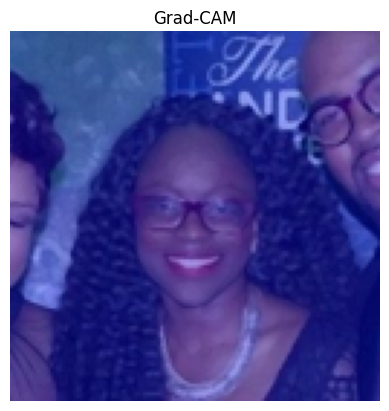

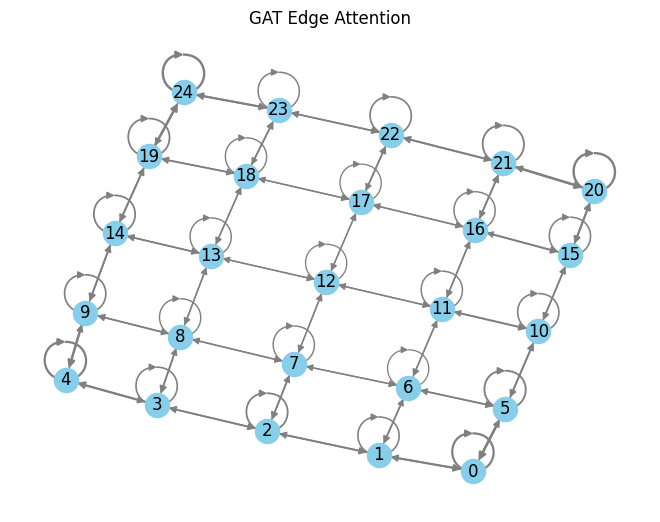

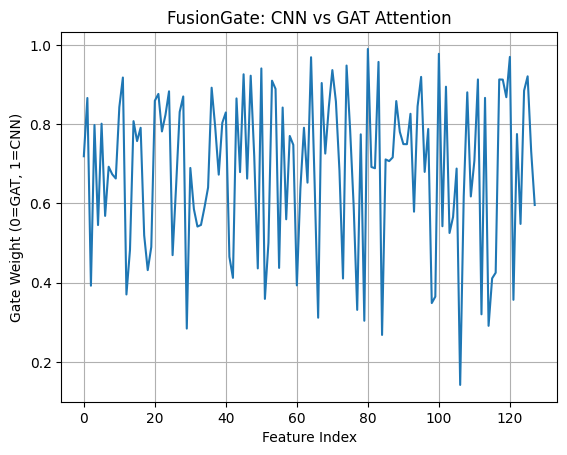

(1, array([0.03914578, 0.96085423], dtype=float32))

In [ ]:
img, graph, label = test_loader.dataset[999]
infer_with_explainability(model, img, graph, label)


AttributeError: 'CNN_GAT_Fusion' object has no attribute 'evaluate'

In [ ]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# ========== METRICS CALCULATION FUNCTION ==========
def compute_metrics(model, loader, device, criterion=None):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, graphs, labels in tqdm(loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)
            graphs = [g.to(device) for g in graphs]

            # Forward pass
            logits = model(images, graphs)

            # Compute loss if criterion is provided
            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * labels.size(0)

            # Get predictions and probabilities
            probs = F.softmax(logits, dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

            total_samples += labels.size(0)

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Compute metrics
    accuracy = (all_preds == all_labels).mean()
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    # Compute AUC-ROC (for binary classification)
    auc_roc = None
    if NUM_CLASSES == 2:
        auc_roc = roc_auc_score(all_labels, all_probs[:, 1])
    else:
        # For multi-class, compute AUC-ROC for each class
        all_labels_bin = label_binarize(all_labels, classes=range(NUM_CLASSES))
        auc_roc = roc_auc_score(all_labels_bin, all_probs, average='weighted', multi_class='ovr')

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Compute average loss if criterion is provided
    avg_loss = total_loss / total_samples if criterion is not None else None

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'confusion_matrix': cm
    }

    if criterion is not None:
        metrics['loss'] = avg_loss

    return metrics

# ========== MODIFIED MAIN ==========
if __name__ == "__main__":
    # Existing setup
    train_loader, val_loader, test_loader = build_dataloaders(DATASET_PATH, BATCH_SIZE, PATCH_SIZE)
    model = CNN_GAT_Fusion().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler()
    criterion = FocalLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early_stopper = EarlyStopping(patience=PATIENCE, mode='max')

    # Training loop
    print("Starting training...")
    for epoch in range(N_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, optimizer, train_loader, criterion, DEVICE, scaler)
        val_loss, val_acc = evaluate(model, val_loader, DEVICE, criterion)
        scheduler.step(val_acc)
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")
        early_stopper(val_acc, model, "best_cnn_gat_fusion.pt")
        if early_stopper.stop:
            print("Early stopping triggered.")
            break

    # Load best model for evaluation
    model.load_state_dict(torch.load("best_cnn_gat_fusion.pt"))

    # Evaluate on test set with metrics
    print("\nEvaluating on Test Set...")
    test_metrics = compute_metrics(model, test_loader, DEVICE, criterion)

    # Print metrics
    print("\nTest Metrics:")
    print(f"Loss: {test_metrics['loss']:.4f}")
    print(f"Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f}")
    print(f"Recall: {test_metrics['recall']:.4f}")
    print(f"F1-Score: {test_metrics['f1_score']:.4f}")
    print(f"AUC-ROC: {test_metrics['auc_roc']:.4f}")
    print("Confusion Matrix:")
    print(test_metrics['confusion_matrix'])

    # Optionally, compute validation metrics
    print("\nEvaluating on Validation Set...")
    val_metrics = compute_metrics(model, val_loader, DEVICE, criterion)

    print("\nValidation Metrics:")
    print(f"Loss: {val_metrics['loss']:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-Score: {val_metrics['f1_score']:.4f}")
    print(f"AUC-ROC: {val_metrics['auc_roc']:.4f}")
    print("Confusion Matrix:")
    print(val_metrics['confusion_matrix'])

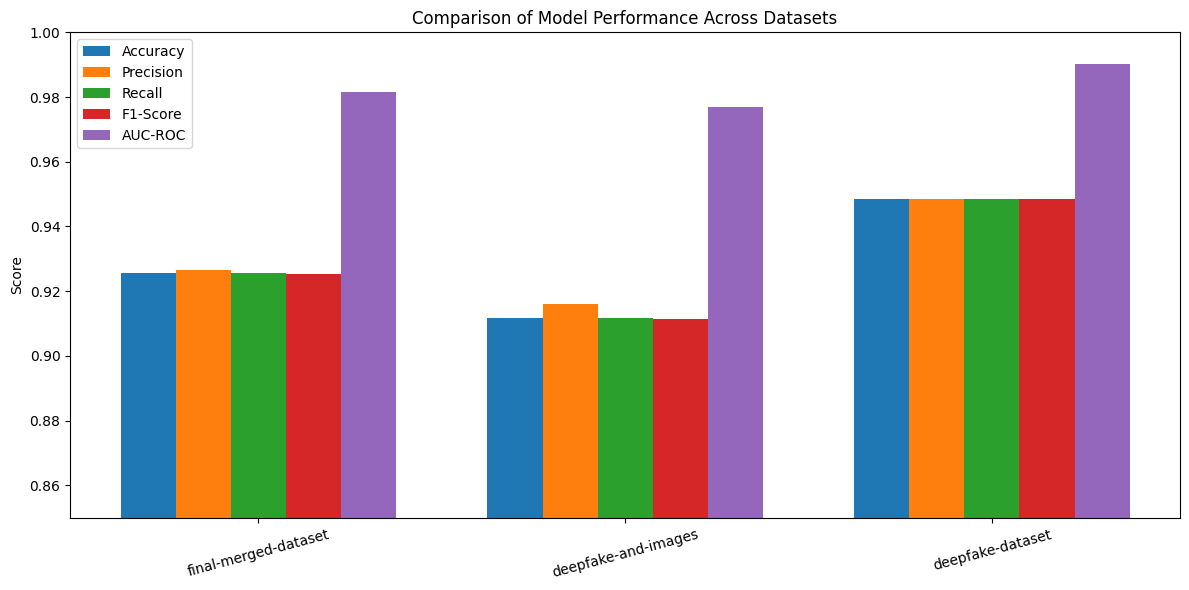

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset names
datasets = [
    "final-merged-dataset",
    "deepfake-and-images",
    "deepfake-dataset"
]

# Metrics
accuracy = [0.9255, 0.9117, 0.9486]
precision = [0.9264, 0.9159, 0.9486]
recall = [0.9255, 0.9117, 0.9486]
f1 = [0.9253, 0.9114, 0.9486]
auc = [0.9815, 0.9770, 0.9903]

# Grouped bar chart setup
x = np.arange(len(datasets))
width = 0.15

plt.figure(figsize=(12,6))
plt.bar(x - 2*width, accuracy, width, label='Accuracy')
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-Score')
plt.bar(x + 2*width, auc, width, label='AUC-ROC')

plt.xticks(x, datasets, rotation=15)
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.title("Comparison of Model Performance Across Datasets")
plt.legend()
plt.tight_layout()
plt.show()
